# End-of-unit project — Predicting fuel economy from car specs 

**Chapter 5 · Unit 2 — Application of Supervised Learning for Numerical Prediction**

> **Student worksheet.** Yellow *Question* boxes are for you to answer in your own words — discuss with a classmate or your instructor. Green *Try it yourself* exercises are open-ended hands-on tasks. The matching instructor notebook contains worked solutions and answers.

## The story

In the 1970s the American auto industry was famously inefficient — big V8 engines, heavy steel bodies, mediocre fuel economy. Then the 1973 oil embargo quintupled gas prices overnight. Suddenly *miles per gallon* became the most important spec of any car, smaller Japanese and European imports began outselling Detroit's land yachts, and Congress passed the first federal fuel-economy standards (CAFE, 1975).

This project uses a famous dataset that captures exactly that decade: **the UCI Auto MPG dataset**, 406 cars from model years 1970–1982 with their fuel economy and engine specifications.

## Your mission

Build a regression model that predicts a car's fuel economy (miles per gallon) from its mechanical specs and origin, exercising every concept from this unit:

1. Loading and inspecting real numerical data
2. Handling missing values
3. Visualizing relationships and spotting non-linearity
4. Encoding categorical features
5. Splitting into train and test sets
6. Training **linear regression** with `LinearRegression`
7. Diagnosing the model — **MSE, RMSE, MAE, R²**, residual analysis
8. Recognizing **multicollinearity** and using **Ridge / Lasso** to handle it
9. Capturing curvature with **Polynomial regression**
10. The **bias–variance tradeoff** — when each technique helps and when each hurts

Color key:

<div style="background-color: #fef3c7; border-left: 4px solid #f59e0b; padding: 8px 12px; margin: 4px 0;"><strong>Question for you</strong> — short conceptual questions.</div>
<div style="background-color: #ede9fe; border-left: 4px solid #7c3aed; padding: 8px 12px; margin: 4px 0;"><strong>Answer</strong> — solutions appear in the instructor notebook.</div>
<div style="background-color: #dbeafe; border-left: 4px solid #3b82f6; padding: 8px 12px; margin: 4px 0;"><strong>Tip</strong> — useful shortcuts and clarifications.</div>
<div style="background-color: #fee2e2; border-left: 4px solid #ef4444; padding: 8px 12px; margin: 4px 0;"><strong>Watch out</strong> — common mistakes to avoid.</div>
<div style="background-color: #dcfce7; border-left: 4px solid #16a34a; padding: 8px 12px; margin: 4px 0;"><strong>Try it yourself</strong> — extended hands-on exercises with worked solutions.</div>


## 0. Setup



In [126]:
# Run once if needed
# %pip install vega_datasets seaborn

In [128]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection  import train_test_split, cross_val_score, KFold
from sklearn.preprocessing    import StandardScaler, PolynomialFeatures
from sklearn.linear_model     import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.metrics          import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

ORIGIN_PALETTE = {"USA": "#D85A30", "Europe": "#534AB7", "Japan": "#1D9E75"}

RANDOM_STATE = 42

In [130]:
# Resilient loader — tries vega_datasets → seaborn → direct CSV download
def load_auto_mpg():
    # 1) vega_datasets (data is bundled inside the package — works offline)
    try:
        from vega_datasets import data
        df = data.cars()
        # Standardize column names and types so the rest of the notebook is portable
        df = df.rename(columns={
            "Miles_per_Gallon": "mpg",
            "Cylinders":        "cylinders",
            "Displacement":     "displacement",
            "Horsepower":       "horsepower",
            "Weight_in_lbs":    "weight",
            "Acceleration":     "acceleration",
            "Year":             "model_year",
            "Origin":           "origin",
            "Name":             "name",
        })
        # Year arrives as a datetime — convert to integer year (70..82)
        df["model_year"] = pd.to_datetime(df["model_year"]).dt.year
        # Cast pandas string-array dtype back to plain object for compatibility
        df["origin"] = df["origin"].astype(str)
        df["name"]   = df["name"].astype(str)
        print("Loaded via vega_datasets.")
        return df
    except Exception as e:
        print(f"vega_datasets loader failed ({type(e).__name__}); trying seaborn…")

    # 2) seaborn ships an mpg dataset
    try:
        df = sns.load_dataset("mpg")
        df = df.rename(columns={"name": "name"})  # already in the right shape
        df["origin"] = df["origin"].str.upper().replace({"USA": "USA"})  # normalise
        print("Loaded via seaborn.")
        return df
    except Exception as e:
        print(f"seaborn loader failed ({type(e).__name__}); trying direct CSV…")

    # 3) direct download (canonical UCI mirror)
    URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
    df = pd.read_csv(URL)
    print("Loaded via direct CSV download.")
    return df

cars = load_auto_mpg()
cars.head()

Loaded via vega_datasets.


,name,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,chevrolet chevelle malibu,18.0,8,307.0,130.0,3504,12.0,1970,USA
1,buick skylark 320,15.0,8,350.0,165.0,3693,11.5,1970,USA
2,plymouth satellite,18.0,8,318.0,150.0,3436,11.0,1970,USA
3,amc rebel sst,16.0,8,304.0,150.0,3433,12.0,1970,USA
4,ford torino,17.0,8,302.0,140.0,3449,10.5,1970,USA


## 1. Inspect the data

Always look at your data before doing anything else.

In [63]:
print(f"Shape: {cars.shape[0]} rows × {cars.shape[1]} columns")
print()
print("Column types:")
print(cars.dtypes)

Shape: 406 rows × 9 columns

Column types:
name             object
mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int32
origin           object
dtype: object


<div style="background-color: #fef3c7; border-left: 4px solid #f59e0b; padding: 12px 16px; border-radius: 4px; margin: 16px 0;"><strong>Question for you</strong><br>Which column is our <strong>target</strong>? Of the rest, which are <strong>numerical</strong>, which are <strong>categorical</strong>, and which one is just an identifier we should drop?</div>

### 1.1 — Distribution of the target

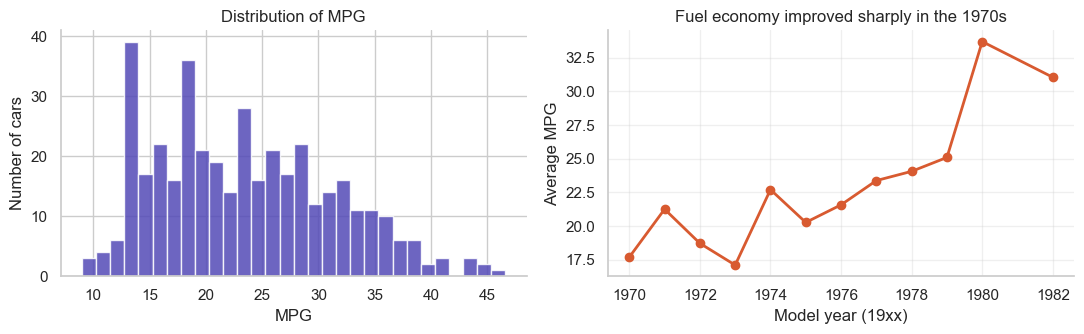

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].hist(cars["mpg"].dropna(), bins=30, color="#534AB7", alpha=0.85)
axes[0].set_xlabel("MPG")
axes[0].set_ylabel("Number of cars")
axes[0].set_title("Distribution of MPG")

# MPG over time — does the oil crisis show up?
year_means = cars.groupby("model_year")["mpg"].mean()
axes[1].plot(year_means.index, year_means.values, "o-", color="#D85A30", linewidth=2)
axes[1].set_xlabel("Model year (19xx)")
axes[1].set_ylabel("Average MPG")
axes[1].set_title("Fuel economy improved sharply in the 1970s")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<div style="background-color: #fef3c7; border-left: 4px solid #f59e0b; padding: 12px 16px; border-radius: 4px; margin: 16px 0;"><strong>Question for you</strong><br>Look at the year-over-year average MPG plot. Cars from the early 1970s averaged around 17–18 MPG; by 1980 they averaged 34. <strong>What real-world events caused this?</strong> And what does it imply we'll need from our model — should it treat year as just another feature, or is there something special about it?</div>

## 2. Handle missing values

In [69]:
missing = cars.isnull().sum()
print(missing[missing > 0])
print(f"\nTotal rows with at least one missing value: {cars.isnull().any(axis=1).sum()}")

mpg           8
horsepower    6
dtype: int64

Total rows with at least one missing value: 14


<div style="background-color: #dbeafe; border-left: 4px solid #3b82f6; padding: 12px 16px; border-radius: 4px; margin: 16px 0;"><strong>Tip</strong><br>Two columns have missing values: <code>mpg</code> (the target) and <code>horsepower</code> (a feature). These call for different treatments:<ul style='margin:6px 0;'><li><strong>Missing target</strong>: we can't train on rows without a label. Drop them.</li><li><strong>Missing feature</strong>: we have options — drop, impute, or use a model that handles missingness natively. We'll impute with the median because horsepower has only a handful of missing values and a clearly skewed distribution.</li></ul></div>

In [71]:
# Drop rows where the target is missing — these are unlabeled, so unusable for supervised learning
cars = cars.dropna(subset=["mpg"]).reset_index(drop=True)

# Impute missing horsepower with the median
hp_median = cars["horsepower"].median()
cars["horsepower"] = cars["horsepower"].fillna(hp_median)

print(f"Imputed missing horsepower with the median ({hp_median:.1f} hp)")
print(f"Remaining rows: {len(cars)}")
print(f"Any missing left? {cars.isnull().any().any()}")

Imputed missing horsepower with the median (93.5 hp)
Remaining rows: 398
Any missing left? False


<div style="background-color: #fef3c7; border-left: 4px solid #f59e0b; padding: 12px 16px; border-radius: 4px; margin: 16px 0;"><strong>Question for you</strong><br>Why use the <strong>median</strong> instead of the <strong>mean</strong> for imputing horsepower? And why is imputing the target column itself a bad idea even when it's tempting?</div>

## 3. Explore the relationships

### 3.1 — How does each numeric feature relate to MPG?

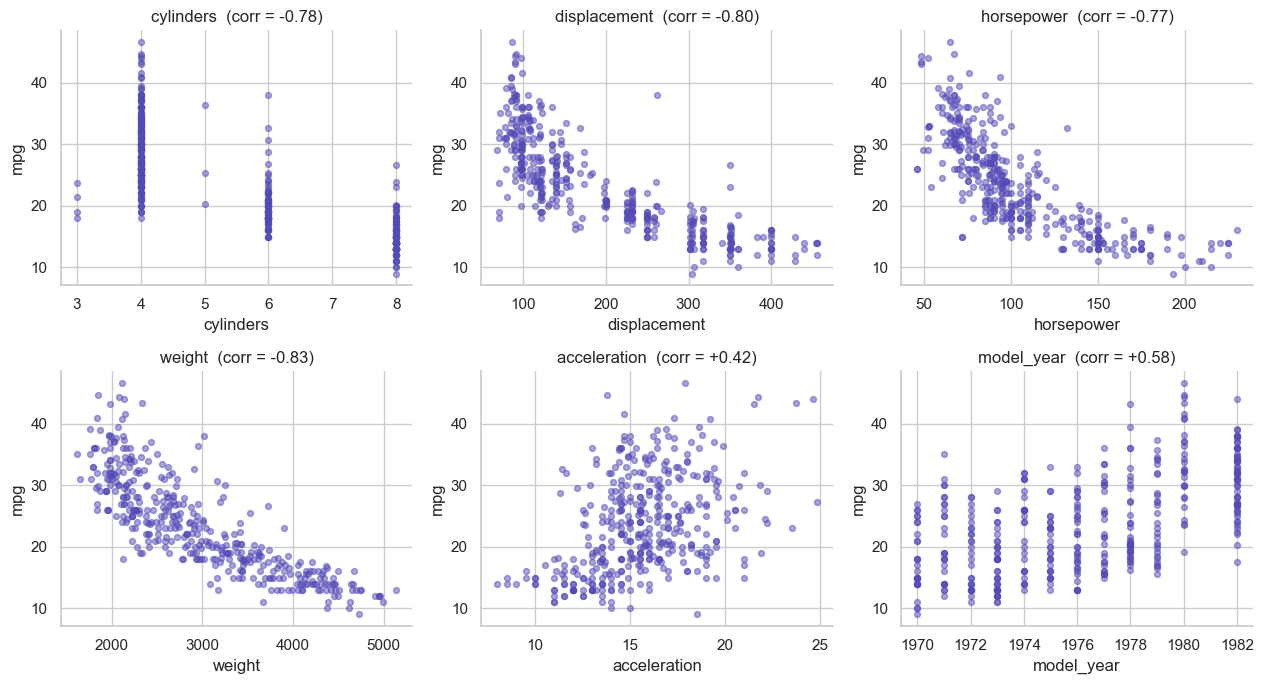

In [75]:
features = ["cylinders", "displacement", "horsepower", "weight",
            "acceleration", "model_year"]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, feat in zip(axes.flat, features):
    ax.scatter(cars[feat], cars["mpg"], alpha=0.5, s=18, color="#534AB7")
    ax.set_xlabel(feat)
    ax.set_ylabel("mpg")
    corr = cars[feat].corr(cars["mpg"])
    ax.set_title(f"{feat}  (corr = {corr:+.2f})")

plt.tight_layout()
plt.show()

<div style="background-color: #fef3c7; border-left: 4px solid #f59e0b; padding: 12px 16px; border-radius: 4px; margin: 16px 0;"><strong>Question for you</strong><br>Look carefully at the scatter plot of <code>mpg</code> vs <code>weight</code>.<br>(a) The Pearson correlation is about &minus;0.83 — very strong. Is the relationship truly <strong>linear</strong>, or does it curve?<br>(b) If it curves, is a linear regression model going to do well, badly, or somewhere in between? What additional technique from this unit could capture the curvature?</div>

### 3.2 — Does origin matter? Does year?

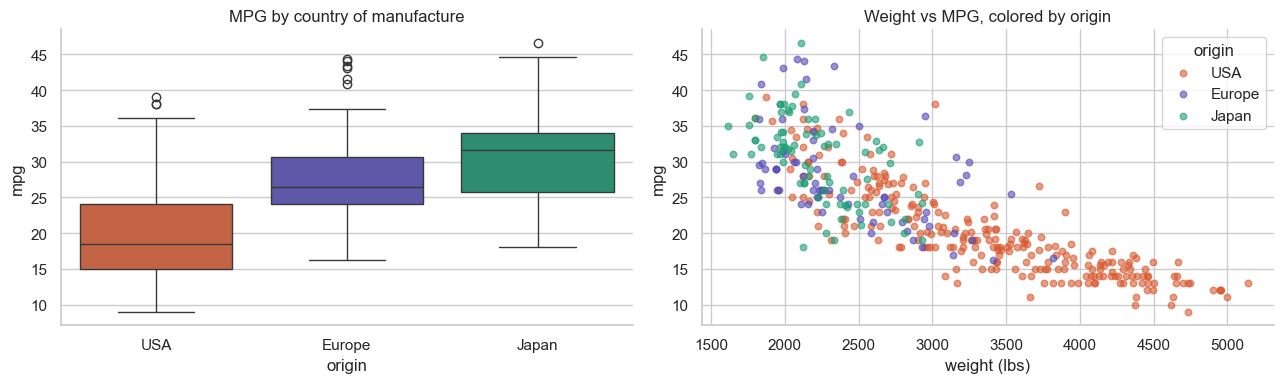

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# MPG by origin
sns.boxplot(data=cars, x="origin", y="mpg", hue="origin", legend=False,
            order=["USA", "Europe", "Japan"],
            palette=ORIGIN_PALETTE, ax=axes[0])
axes[0].set_title("MPG by country of manufacture")

# Weight vs MPG, colored by origin — story plot
for orig, color in ORIGIN_PALETTE.items():
    sub = cars[cars["origin"] == orig]
    axes[1].scatter(sub["weight"], sub["mpg"], alpha=0.6, s=22,
                    color=color, label=orig)
axes[1].set_xlabel("weight (lbs)")
axes[1].set_ylabel("mpg")
axes[1].set_title("Weight vs MPG, colored by origin")
axes[1].legend(title="origin")

plt.tight_layout()
plt.show()

<div style="background-color: #fef3c7; border-left: 4px solid #f59e0b; padding: 12px 16px; border-radius: 4px; margin: 16px 0;"><strong>Question for you</strong><br>(a) Looking at the boxplot, which country's cars averaged the best fuel economy?<br>(b) Looking at the scatter on the right, do Japanese cars get better MPG than American cars <em>at the same weight</em>, or are they just lighter on average? This is an important distinction.</div>

## 4. The multicollinearity problem

Before we encode and split, look carefully at how the *features* relate to *each other*.

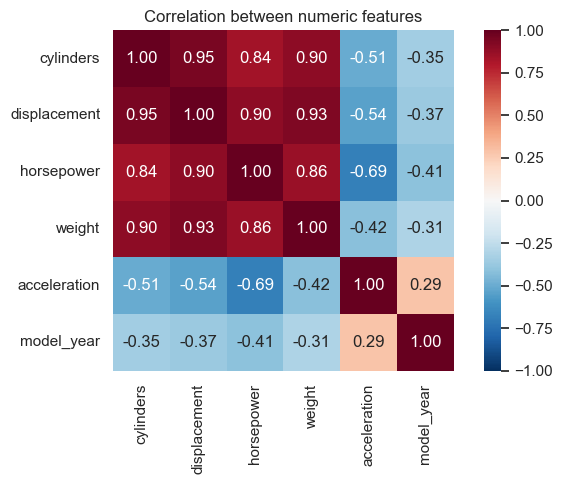

In [81]:
numeric_features = ["cylinders", "displacement", "horsepower", "weight",
                    "acceleration", "model_year"]
corr = cars[numeric_features].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation between numeric features")
plt.tight_layout()
plt.show()

<div style="background-color: #fee2e2; border-left: 4px solid #ef4444; padding: 12px 16px; border-radius: 4px; margin: 16px 0;"><strong>Watch out</strong><br>Look at the upper-left block: <code>cylinders</code>, <code>displacement</code>, <code>horsepower</code>, and <code>weight</code> are all <strong>0.84 to 0.95 correlated with each other</strong>. This is called <strong>multicollinearity</strong>, and it's a problem for ordinary linear regression.<br><br>Why is it a problem? If two features always move together, the model can't tell which one is doing the work — a coefficient of (+5 on weight, −3 on horsepower) might fit the data just as well as (+10 on weight, −8 on horsepower). The math still finds a solution, but the individual coefficients become unstable and lose their interpretive meaning. This is exactly the situation <em>Ridge</em> and <em>Lasso</em> regression are designed to handle — we'll use them in §8.</div>

<div style="background-color: #fef3c7; border-left: 4px solid #f59e0b; padding: 12px 16px; border-radius: 4px; margin: 16px 0;"><strong>Question for you</strong><br>Does multicollinearity hurt the model's <strong>prediction accuracy</strong>, its <strong>coefficient interpretability</strong>, or both? Think carefully — they aren't always the same thing.</div>

## 5. Encode origin and split into train / test

In [85]:
# One-hot encode the categorical column
cars_encoded = pd.get_dummies(cars, columns=["origin"], drop_first=False)

# Drop the identifier column
cars_encoded = cars_encoded.drop(columns=["name"])

print("Final feature columns:")
print(list(cars_encoded.columns))

Final feature columns:
['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin_Europe', 'origin_Japan', 'origin_USA']


In [86]:
X = cars_encoded.drop(columns=["mpg"])
y = cars_encoded["mpg"]

# Make sure all features are float (booleans from get_dummies become 0/1 floats)
X = X.astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Training: {len(X_train)} cars   Testing: {len(X_test)} cars")
print(f"Features: {X.shape[1]}")

Training: 318 cars   Testing: 80 cars
Features: 9


<div style="background-color: #dbeafe; border-left: 4px solid #3b82f6; padding: 12px 16px; border-radius: 4px; margin: 16px 0;"><strong>Tip</strong><br>Notice we did <strong>not</strong> use <code>stratify</code> here. Stratification is for <em>classification</em> tasks where we want to preserve the proportion of each class in train and test. In regression the target is continuous, so there are no classes to preserve. The default random shuffle is fine.</div>

## 6. Fit a Linear Regression and diagnose it

Time for the simplest possible model: ordinary linear regression. We'll fit it, then run it through every diagnostic from §2.3 of the slides.

In [89]:
linreg = LinearRegression()
linreg.fit(X_train, y_train)

y_train_pred = linreg.predict(X_train)
y_test_pred  = linreg.predict(X_test)

def regression_report(y_true, y_pred, label):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"{label:>12s}:  MSE={mse:6.2f}   RMSE={rmse:5.2f}   MAE={mae:5.2f}   R²={r2:.3f}")

regression_report(y_train, y_train_pred, "TRAIN")
regression_report(y_test,  y_test_pred,  "TEST")

       TRAIN:  MSE= 11.44   RMSE= 3.38   MAE= 2.60   R²=0.817
        TEST:  MSE=  8.16   RMSE= 2.86   MAE= 2.26   R²=0.848


<div style="background-color: #fef3c7; border-left: 4px solid #f59e0b; padding: 12px 16px; border-radius: 4px; margin: 16px 0;"><strong>Question for you</strong><br>Compare the four metrics:<br>(a) <strong>RMSE</strong> is in the same units as the target (MPG). What does the test RMSE of about 3.2 actually mean in plain English?<br>(b) <strong>MAE</strong> is also in MPG, and is smaller than RMSE. Why is MAE always ≤ RMSE? Which one is more sensitive to outliers?<br>(c) <strong>R²</strong> compares your model to a 'baseline that just predicts the mean'. What is R² of 0.82 telling you about how much better than that baseline this model does?</div>

### 6.1 — Predicted vs actual plot

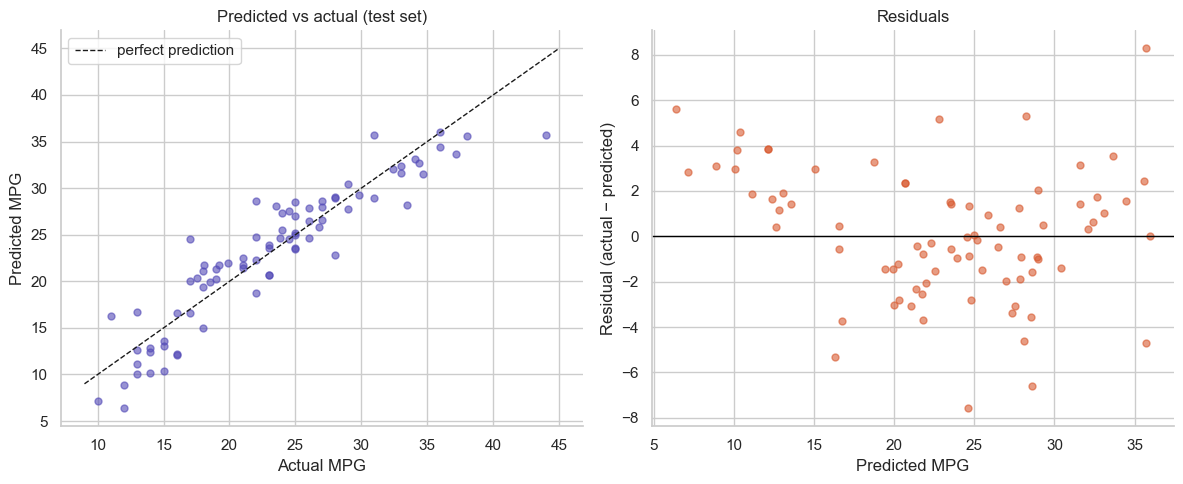

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Predicted vs actual on test
axes[0].scatter(y_test, y_test_pred, alpha=0.6, color="#534AB7", s=25)
lims = [y_test.min() - 1, y_test.max() + 1]
axes[0].plot(lims, lims, "k--", linewidth=1, label="perfect prediction")
axes[0].set_xlabel("Actual MPG")
axes[0].set_ylabel("Predicted MPG")
axes[0].set_title("Predicted vs actual (test set)")
axes[0].legend()

# Residual plot
residuals = y_test - y_test_pred
axes[1].scatter(y_test_pred, residuals, alpha=0.6, color="#D85A30", s=25)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_xlabel("Predicted MPG")
axes[1].set_ylabel("Residual (actual − predicted)")
axes[1].set_title("Residuals")

plt.tight_layout()
plt.show()

<div style="background-color: #fef3c7; border-left: 4px solid #f59e0b; padding: 12px 16px; border-radius: 4px; margin: 16px 0;"><strong>Question for you</strong><br>Look at the <strong>residual plot</strong> on the right. We learned in the slides that residuals for a well-fitted linear model should be:<ul><li>Centered around zero ✓</li><li>Have constant variance across the range of predictions</li><li>Show <strong>no pattern</strong> — just a random cloud</li></ul>Do our residuals satisfy all three? If not, which assumption is being violated, and what does that imply about our model?</div>

### 6.2 — What did the model learn?

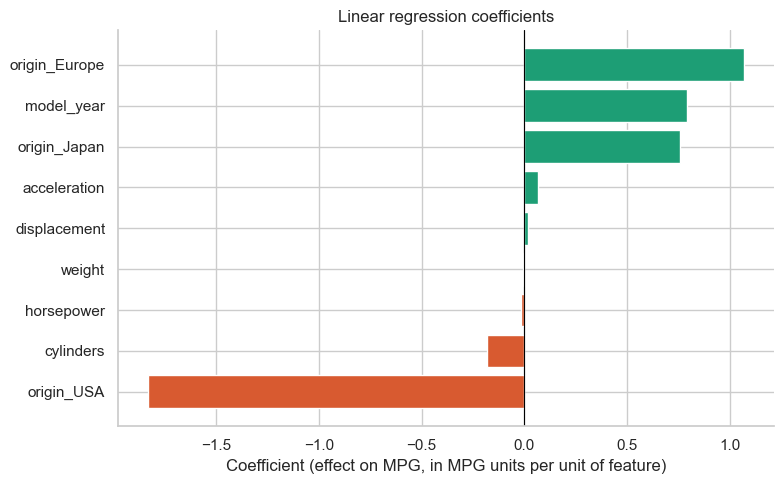

Intercept (baseline MPG): -1524.38


In [95]:
coefs = pd.Series(linreg.coef_, index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#D85A30" if c < 0 else "#1D9E75" for c in coefs]
ax.barh(coefs.index, coefs.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficient (effect on MPG, in MPG units per unit of feature)")
ax.set_title("Linear regression coefficients")
plt.tight_layout()
plt.show()

print(f"Intercept (baseline MPG): {linreg.intercept_:.2f}")

<div style="background-color: #fef3c7; border-left: 4px solid #f59e0b; padding: 12px 16px; border-radius: 4px; margin: 16px 0;"><strong>Question for you</strong><br>Look at the coefficient plot. Several things should jump out as strange:<br>(a) <code>weight</code> has a coefficient near zero, but we saw in §3 that weight is the most strongly correlated single feature with MPG. <code>horsepower</code> and <code>displacement</code> are also near zero. Where did all the engine-size signal go?<br>(b) The largest coefficients belong to the <code>origin_*</code> dummies. Does that mean origin is the most important feature, or could the visual be misleading us?</div>

## 7. Cross-validate the baseline

Before reaching for fancier models, get a more honest picture of how this baseline really performs.

In [98]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# We score on negative MSE because cross_val_score maximizes; flip the sign back
neg_mse = cross_val_score(LinearRegression(), X_train, y_train,
                          cv=cv, scoring="neg_mean_squared_error")
rmse_folds = np.sqrt(-neg_mse)

r2_folds = cross_val_score(LinearRegression(), X_train, y_train,
                           cv=cv, scoring="r2")

print("RMSE per fold:", np.round(rmse_folds, 3))
print(f"  mean: {rmse_folds.mean():.3f}   std: {rmse_folds.std():.3f}")
print()
print("R² per fold:  ", np.round(r2_folds, 3))
print(f"  mean: {r2_folds.mean():.3f}   std: {r2_folds.std():.3f}")

RMSE per fold: [3.634 3.813 3.268 3.136 3.578]
  mean: 3.486   std: 0.248

R² per fold:   [0.81  0.768 0.806 0.804 0.823]
  mean: 0.802   std: 0.018


## 8. Tame multicollinearity with Ridge and Lasso

Both Ridge and Lasso add a penalty to the loss function that discourages large coefficients. The penalty's strength is a hyperparameter (`alpha` in scikit-learn). Larger `alpha` means stronger penalty, which means smaller coefficients but more bias.

<div style="background-color: #fee2e2; border-left: 4px solid #ef4444; padding: 12px 16px; border-radius: 4px; margin: 16px 0;"><strong>Watch out</strong><br>Two important rules apply when we use <code>StandardScaler</code> in the next cell:<br><ol style='margin:6px 0;'><li><strong>Always standardize features before applying Ridge or Lasso.</strong> Both methods are sensitive to feature scale — a feature measured in thousands of pounds (weight) will get a tiny coefficient just because of its units, and the penalty will hit features unevenly.</li><li><strong>Fit the scaler on training data only.</strong> Use <code>scaler.fit_transform(X_train)</code> first, then <code>scaler.transform(X_test)</code> — never the other way round, and never <code>fit_transform</code> on the test set. Otherwise the scaler 'sees' the test data during training and your evaluation becomes optimistic. Same lesson as the breast cancer notebook.</li></ol></div>

In [101]:
# Standardize the features. We fit the scaler on training data ONLY,
# then apply the same transformation to test data — no leakage.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Now fit Ridge and Lasso on the scaled training data
ridge = Ridge().fit(X_train_scaled, y_train)
lasso = Lasso(max_iter=10000).fit(X_train_scaled, y_train)

# Compare test performance — note that OLS uses the original (unscaled) X,
# while Ridge and Lasso use the scaled version.
print("Test set comparison:")
print()
y_pred_ols = linreg.predict(X_test)
print(f"  OLS    RMSE={np.sqrt(mean_squared_error(y_test, y_pred_ols)):.3f}   "
      f"R²={r2_score(y_test, y_pred_ols):.3f}")

for name, model in [("Ridge", ridge), ("Lasso", lasso)]:
    y_pred = model.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    print(f"  {name:6s} RMSE={rmse:.3f}   R²={r2:.3f}")

Test set comparison:

  OLS    RMSE=2.857   R²=0.848
  Ridge  RMSE=2.859   R²=0.848
  Lasso  RMSE=2.945   R²=0.839


### 8.1 — Pick the right `alpha` with cross-validation

In [103]:
# RidgeCV and LassoCV automate the alpha search using cross-validation.
# We re-use the X_train_scaled / X_test_scaled arrays we built above.
ridge_cv = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5).fit(X_train_scaled, y_train)
lasso_cv = LassoCV(alphas=np.logspace(-3, 1, 50), cv=5,
                   max_iter=20000, random_state=RANDOM_STATE).fit(X_train_scaled, y_train)

print(f"Best Ridge alpha: {ridge_cv.alpha_:.4f}")
print(f"Best Lasso alpha: {lasso_cv.alpha_:.4f}")
print()

print("Test set with tuned alphas:")
for name, model in [("Ridge (tuned)", ridge_cv),
                    ("Lasso (tuned)", lasso_cv)]:
    y_pred = model.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    print(f"  {name:14s}  RMSE={rmse:.3f}   R²={r2:.3f}")

Best Ridge alpha: 2.0236
Best Lasso alpha: 0.0202

Test set with tuned alphas:
  Ridge (tuned)   RMSE=2.862   R²=0.848
  Lasso (tuned)   RMSE=2.881   R²=0.846


### 8.2 — Compare the coefficients

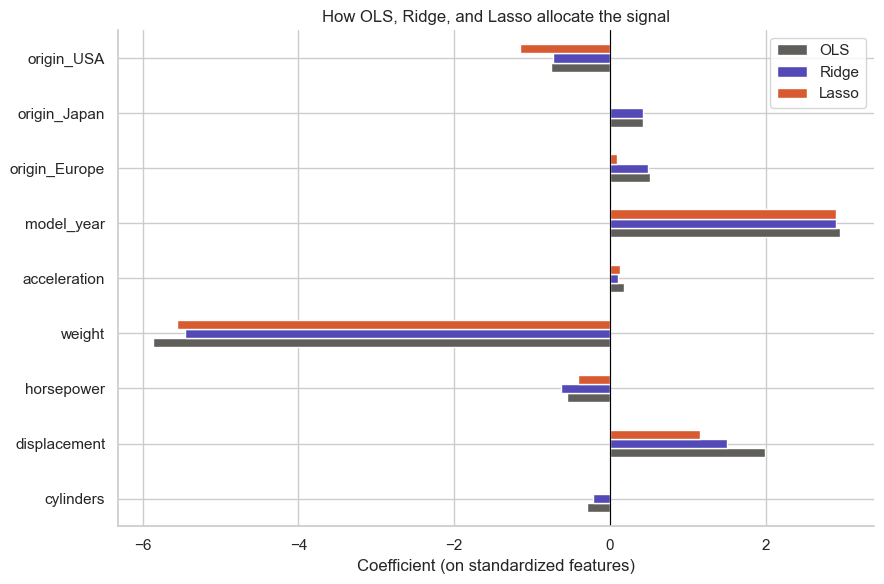

                 OLS  Ridge  Lasso
cylinders     -0.301 -0.224 -0.000
displacement   1.991  1.503  1.160
horsepower    -0.550 -0.633 -0.417
weight        -5.870 -5.451 -5.564
acceleration   0.185  0.102  0.132
model_year     2.948  2.895  2.907
origin_Europe  0.514  0.486  0.094
origin_Japan   0.422  0.422  0.000
origin_USA    -0.754 -0.732 -1.156


In [105]:
# We compare standardized coefficients so the magnitudes are comparable across features.
# Refit OLS on the scaled training data for an apples-to-apples comparison.
ols_scaled = LinearRegression().fit(X_train_scaled, y_train)

coef_df = pd.DataFrame({
    "OLS":   ols_scaled.coef_,
    "Ridge": ridge_cv.coef_,
    "Lasso": lasso_cv.coef_,
}, index=X.columns)

ax = coef_df.plot(kind="barh", figsize=(9, 6),
                  color=["#5F5E5A", "#534AB7", "#D85A30"])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficient (on standardized features)")
ax.set_title("How OLS, Ridge, and Lasso allocate the signal")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

print(coef_df.round(3))

<div style="background-color: #fef3c7; border-left: 4px solid #f59e0b; padding: 12px 16px; border-radius: 4px; margin: 16px 0;"><strong>Question for you</strong><br>(a) Which Lasso coefficients are exactly zero, and what does that tell you?<br>(b) Compare OLS and Ridge: which features got their coefficients <em>shrunk</em> by Ridge (i.e. moved closer to zero)?<br>(c) Of the three models, which one would you ship? Defend your choice on more than just test-set RMSE.</div>

## 9. Capture the curvature with polynomial regression

Back in §6, the residual plot showed a clear curved pattern — the linear model can't bend. **Polynomial regression** lets us fit curves while still using `LinearRegression` under the hood. We just add `weight²`, `weight × horsepower`, etc., as new features.

In [108]:
# Helper: train a polynomial regression at a given degree, with or without Ridge regularization.
# We re-use X_train_scaled / X_test_scaled from §8 — no need to rescale.
def fit_polynomial(degree, regularize=False):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_p = poly.fit_transform(X_train_scaled)
    X_test_p  = poly.transform(X_test_scaled)
    if regularize:
        model = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5).fit(X_train_p, y_train)
    else:
        model = LinearRegression().fit(X_train_p, y_train)
    return {
        "degree":      degree,
        "regularized": regularize,
        "RMSE_train":  np.sqrt(mean_squared_error(y_train, model.predict(X_train_p))),
        "RMSE_test":   np.sqrt(mean_squared_error(y_test,  model.predict(X_test_p))),
        "R²_test":     r2_score(y_test, model.predict(X_test_p)),
        "n_features":  X_train_p.shape[1],
    }

results = []
for degree in [1, 2, 3]:
    for reg in [False, True]:
        if degree == 1 and reg:
            continue  # equivalent to plain Ridge from §8
        results.append(fit_polynomial(degree, regularize=reg))

results_df = pd.DataFrame(results)
print(results_df.round(3).to_string(index=False))

 degree  regularized  RMSE_train    RMSE_test       R²_test  n_features
      1        False       3.383 2.857000e+00  8.480000e-01           9
      2        False       2.595 2.252000e+00  9.060000e-01          54
      2         True       2.653 2.062000e+00  9.210000e-01          54
      3        False       1.731 4.406023e+09 -3.610623e+17         219
      3         True       2.366 2.091000e+00  9.190000e-01         219


<div style="background-color: #fef3c7; border-left: 4px solid #f59e0b; padding: 12px 16px; border-radius: 4px; margin: 16px 0;"><strong>Question for you</strong><br>Look carefully at the table:<br>(a) <strong>Degree 1 (linear)</strong>: train and test RMSE are similar (~3.0). What does that tell you?<br>(b) <strong>Degree 2, no regularization</strong>: train RMSE drops further but test RMSE may go up or down. What's happening?<br>(c) <strong>Degree 3, no regularization</strong>: train RMSE plummets but test RMSE goes haywire (often much higher than degree 1). What classic ML phenomenon is this, and why does adding Ridge regularization rescue it?</div>

## 10. The final scoreboard

Let's gather every model we've built and compare them honestly on the held-out test set.

In [112]:
# Re-fit the two polynomial models and keep the transformed test arrays so we can predict
poly2 = PolynomialFeatures(degree=2, include_bias=False)
X_train_p2 = poly2.fit_transform(X_train_scaled)
X_test_p2  = poly2.transform(X_test_scaled)
# poly2_lr   = LinearRegression().fit(X_train_p2, y_train)
poly2_ridge  =  RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5).fit(X_train_p2, y_train)

poly3 = PolynomialFeatures(degree=3, include_bias=False)
X_train_p3 = poly3.fit_transform(X_train_scaled)
X_test_p3  = poly3.transform(X_test_scaled)
poly3_ridge = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5).fit(X_train_p3, y_train)

# Each model needs its own version of X_test because of the different transformations
predictions = {
    "OLS Linear":               linreg.predict(X_test),
    "Ridge (tuned alpha)":      ridge_cv.predict(X_test_scaled),
    "Lasso (tuned alpha)":      lasso_cv.predict(X_test_scaled),
    "Polynomial deg 2 + Ridge": poly2_ridge.predict(X_test_p2),
    "Polynomial deg 3 + Ridge": poly3_ridge.predict(X_test_p3),
}

scoreboard = []
for name, y_pred in predictions.items():
    scoreboard.append({
        "Model":  name,
        "RMSE":   np.sqrt(mean_squared_error(y_test, y_pred)),
        "MAE":    mean_absolute_error(y_test, y_pred),
        "R²":     r2_score(y_test, y_pred),
    })

scoreboard_df = pd.DataFrame(scoreboard).sort_values("RMSE")
print(scoreboard_df.round(3).to_string(index=False))

                   Model  RMSE   MAE    R²
Polynomial deg 2 + Ridge 2.062 1.589 0.921
Polynomial deg 3 + Ridge 2.091 1.570 0.919
              OLS Linear 2.857 2.264 0.848
     Ridge (tuned alpha) 2.862 2.263 0.848
     Lasso (tuned alpha) 2.881 2.267 0.846


<div style="background-color: #fef3c7; border-left: 4px solid #f59e0b; padding: 12px 16px; border-radius: 4px; margin: 16px 0;"><strong>Question for you</strong><br>Look at the final scoreboard. Three big-picture questions:<br>(a) <em>Polynomial deg 2 or deg 3 + Ridge</em> usually beats both pure linear and pure Ridge. Why does stacking those two ideas work better than either alone?<br>(b) Suppose you're deploying this to production. The simplest model is OLS, the most accurate is Polynomial+Ridge. What considerations beyond RMSE should drive your choice?</div>

## 11. Stretch exercises


<div style="background-color: #dcfce7; border-left: 4px solid #16a34a; padding: 12px 16px; border-radius: 4px; margin: 16px 0;"><strong>Try it yourself</strong><br><strong>1. Recreate the residual plot for the Polynomial deg 2 model.</strong> Has the curved pattern from §6.1 disappeared? What about heteroscedasticity?</div>

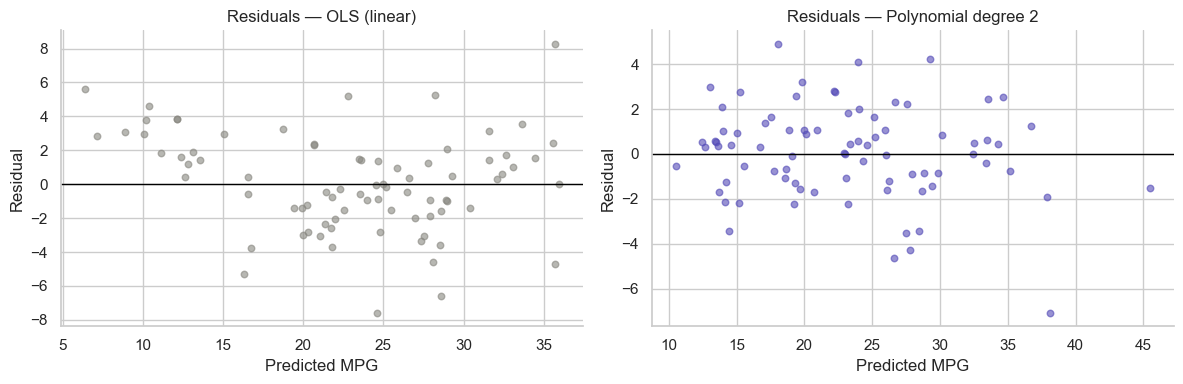

In [114]:
y_pred_poly2 = poly2_ridge.predict(X_test_p2)
residuals_poly2 = y_test - y_pred_poly2

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_test_pred, y_test - y_test_pred, alpha=0.6, color="#888780", s=22)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Residuals — OLS (linear)")
axes[0].set_xlabel("Predicted MPG")
axes[0].set_ylabel("Residual")

axes[1].scatter(y_pred_poly2, residuals_poly2, alpha=0.6, color="#534AB7", s=22)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Residuals — Polynomial degree 2")
axes[1].set_xlabel("Predicted MPG")
axes[1].set_ylabel("Residual")

plt.tight_layout()
plt.show()

<div style="background-color: #dcfce7; border-left: 4px solid #16a34a; padding: 12px 16px; border-radius: 4px; margin: 16px 0;"><strong>Try it yourself</strong><br><strong>2. Try Elastic Net.</strong> Elastic Net combines L1 (Lasso) and L2 (Ridge) penalties. Use <code>ElasticNetCV</code> to find good values of <code>alpha</code> and <code>l1_ratio</code>. Does it beat Ridge or Lasso alone on test RMSE?</div>

In [116]:
from sklearn.linear_model import ElasticNetCV

# We already have X_train_scaled and X_test_scaled from §8 — re-use them
elnet = ElasticNetCV(
    alphas    = np.logspace(-3, 1, 50),
    l1_ratio  = [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99],
    cv        = 5,
    max_iter  = 20000,
    random_state=RANDOM_STATE,
).fit(X_train_scaled, y_train)

print(f"Best alpha:    {elnet.alpha_:.4f}")
print(f"Best l1_ratio: {elnet.l1_ratio_:.2f}")
print()

# Compare to Ridge and Lasso on the same test set
print("Test RMSE comparison:")
for name, model in [("Ridge",       ridge_cv),
                    ("Lasso",       lasso_cv),
                    ("Elastic Net", elnet)]:
    rmse = np.sqrt(mean_squared_error(y_test, model.predict(X_test_scaled)))
    print(f"  {name:12s} {rmse:.3f}")

Best alpha:    0.0079
Best l1_ratio: 0.10

Test RMSE comparison:
  Ridge        2.862
  Lasso        2.881
  Elastic Net  2.864


<div style="background-color: #dcfce7; border-left: 4px solid #16a34a; padding: 12px 16px; border-radius: 4px; margin: 16px 0;"><strong>Try it yourself</strong><br><strong>3. Predict log(MPG) instead of MPG.</strong> One reason linear regression struggles is that MPG is bounded below by zero and right-skewed. A common fix is to predict <code>log(mpg)</code> instead, since the log relationship between weight and <code>1/mpg</code> (gallons per mile, the actual physical quantity) is closer to linear. Refit OLS on <code>log(mpg)</code>, then compute test RMSE on the original MPG scale. Does it beat the linear baseline?</div>

In [118]:
from sklearn.linear_model import LinearRegression

# Train on log(mpg)
y_train_log = np.log(y_train)
y_test_log  = np.log(y_test)

logreg = LinearRegression().fit(X_train, y_train_log)
y_pred_log = logreg.predict(X_test)

# Convert predictions back to the original MPG scale to compare apples-to-apples
y_pred_mpg = np.exp(y_pred_log)

rmse_log_model = np.sqrt(mean_squared_error(y_test, y_pred_mpg))
rmse_baseline  = np.sqrt(mean_squared_error(y_test, linreg.predict(X_test)))

print(f"OLS predicting MPG directly:    RMSE={rmse_baseline:.3f}")
print(f"OLS predicting log(MPG):        RMSE={rmse_log_model:.3f}")
print(f"  (after exp() back to MPG)")
print()
print(f"R² on log scale: {r2_score(y_test_log, y_pred_log):.3f}")
print(f"R² on MPG scale (back-transformed): {r2_score(y_test, y_pred_mpg):.3f}")

OLS predicting MPG directly:    RMSE=2.857
OLS predicting log(MPG):        RMSE=2.361
  (after exp() back to MPG)

R² on log scale: 0.889
R² on MPG scale (back-transformed): 0.896


## 12. Recap

You walked through the full numerical-prediction toolkit:

| Step | What you did | scikit-learn tool |
|---|---|---|
| Load | Raw DataFrame from a public dataset | `vega_datasets.cars` / `seaborn.load_dataset` |
| Clean | Dropped rows with missing target, imputed missing horsepower | `pd.DataFrame.dropna`, `pd.fillna` |
| Encode | One-hot for `origin` | `pd.get_dummies` |
| Split | 20% held-out test set | `train_test_split` |
| Scale | Standardized features for Ridge / Lasso / polynomial | `StandardScaler` |
| Fit | OLS, Ridge, Lasso, Polynomial regression | `LinearRegression`, `Ridge`, `Lasso`, `PolynomialFeatures` |
| Tune | CV-selected `alpha` for Ridge / Lasso / ElasticNet | `RidgeCV`, `LassoCV`, `ElasticNetCV` |
| Diagnose | MSE, RMSE, MAE, R²; residual analysis; predicted-vs-actual | `mean_squared_error`, `r2_score` |
| Compare | Side-by-side scoreboard; bias–variance tradeoff | — |

### Where to go next

The next unit moves from <em>numerical prediction</em> to <em>classification</em> (Unit 3): logistic regression and proper classification metrics. Most of the workflow you practiced here transfers directly — only the model and the metrics change. Preprocessing, cross-validation, and the bias–variance lens you developed in this project are tools you'll keep using for the rest of the chapter.
